# Эксперименты с моделями

Проведём сравнение нескольких моделей для задачи регрессии – предсказания `log_total_revenue` (логарифм общего дохода игры).

**Модели в эксперименте:**
1. Lasso Regression
2. Decision Tree
3. Random Forest
4. XGBoost
5. LightGBM
6. Ансамбль (Stacking)

## Исходные данные

На предыдущем шаге мы подготовили Baseline-модель со следующими параметрами:
* RMSE=1.3366
* MAE=1.0160
* R²=0.5517

Повторим pipeline из `02_baseline.ipynb`:

In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/eda_processed.csv")
assert 'log_total_revenue' in df.columns, "Нет log_total_revenue!"
print("Датасет загружен, форма:", df.shape)

Датасет загружен, форма: (9980, 34)


In [2]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

TEST_SIZE = 0.15
VALIDATION_SIZE = 0.15

X = df.drop(columns=['total_revenue_usd', 'log_total_revenue'])
y = df['log_total_revenue']

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
val_size = VALIDATION_SIZE / (1 - TEST_SIZE)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_size, random_state=RANDOM_STATE
)

X_train = X_train.drop(columns=['developer_name'])
X_val = X_val.drop(columns=['developer_name'])
X_test = X_test.drop(columns=['developer_name'])

print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

Train: 6986, Val: 1497, Test: 1497


In [3]:
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import Ridge


cat_features = X_train.select_dtypes(include=['str', 'bool']).columns.tolist()

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe.fit(X_train[cat_features])

def encode(df, encoder, cat_cols):
    encoded = encoder.transform(df[cat_cols])
    encoded_cols = encoder.get_feature_names_out(cat_cols)
    encoded_df = pd.DataFrame(encoded, index=df.index, columns=encoded_cols)
    df = df.drop(columns=cat_cols)
    return pd.concat([df, encoded_df], axis=1)

X_train_encoded = encode(X_train, ohe, cat_features)
X_val_encoded = encode(X_val, ohe, cat_features)
X_test_encoded = encode(X_test, ohe, cat_features)

baseline_model = Ridge(alpha=1.0, random_state=RANDOM_STATE)
baseline_model.fit(X_train_encoded, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",42


Определим вспомогательную функцию для расчёта метрик.

In [4]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate(name, model, X, y_true):
    y_pred = model.predict(X)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"{name}: RMSE={rmse:.4f}, MAE={mae:.4f}, R²={r2:.4f}")
    return {'Модель': name, 'RMSE': rmse, 'MAE': mae, 'R²': r2}

Создадим словарь результатов и заполним его первым значением (Baseline).

In [ ]:
results = []

res_baseline = evaluate("Baseline", baseline_model, X_val_encoded, y_val)
results.append(res_baseline)

Baseline: RMSE=1.3366, MAE=1.0160, R²=0.5517


## Модель 1 — Lasso Regression

Lasso добавляет L1-регуляризацию, которая автоматически обнуляет веса незначимых признаков. 
Это полезно, когда после OHE признаков становится много — Lasso выполняет встроенный отбор фич.

Подбереём гиперпараметры alpha для Lasso через GridSearchCV.

In [7]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

lasso_params = {'alpha': [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0]}
lasso_cv = GridSearchCV(
    Lasso(max_iter=5000, random_state=RANDOM_STATE),
    param_grid=lasso_params,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
lasso_cv.fit(X_train_encoded, y_train)
print("Лучший alpha:", lasso_cv.best_params_)

lasso_best = lasso_cv.best_estimator_

# Посмотрим, сколько признаков обнулил Lasso
n_zero = np.sum(lasso_best.coef_ == 0)
n_total = len(lasso_best.coef_)
print(f"Обнулено признаков: {n_zero} из {n_total} ({n_zero/n_total:.1%})")

Лучший alpha: {'alpha': 0.001}
Обнулено признаков: 31 из 99 (31.3%)


Добавим результат.

In [8]:
res_lasso = evaluate("Lasso Regression", lasso_best, X_val_encoded, y_val)
results.append(res_lasso)

Lasso Regression: RMSE=1.3348, MAE=1.0144, R²=0.5529


## Модель 2 — Decision Tree

Дерево решений — нелинейная модель, которая строит бинарные разбиения. Нужно ограничивать глубину, чтобы избежать переобучение.

In [9]:
from sklearn.tree import DecisionTreeRegressor

dt_params = {
    'max_depth': [3, 5, 8, 12, None],
    'min_samples_leaf': [1, 5, 10, 20]
}
dt_cv = GridSearchCV(
    DecisionTreeRegressor(random_state=RANDOM_STATE),
    param_grid=dt_params,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
dt_cv.fit(X_train_encoded, y_train)
print("Лучшие параметры DT:", dt_cv.best_params_)
dt_best = dt_cv.best_estimator_

Лучшие параметры DT: {'max_depth': 5, 'min_samples_leaf': 5}


Добавим результат.

In [10]:
res_dt = evaluate("Decision Tree", dt_best, X_val_encoded, y_val)
results.append(res_dt)

Decision Tree: RMSE=1.3669, MAE=1.0456, R²=0.5311


## Модель 3 — Random Forest

Random Forest — ансамбль из деревьев решений. Каждое дерево обучается на случайной подвыборке данных и признаков.

In [11]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

rf_params = {
    'n_estimators': [100, 300],
    'max_depth': [8, 15, None],
    'min_samples_leaf': [1, 5],
    'max_features': ['sqrt', 0.5]
}
rf_cv = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=rf_params,
    n_iter=16,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_cv.fit(X_train_encoded, y_train)
print("Лучшие параметры RF:", rf_cv.best_params_)

rf_best = rf_cv.best_estimator_


Лучшие параметры RF: {'n_estimators': 300, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 8}


Добавим результат.

In [12]:
res_rf = evaluate("Random Forest", rf_best, X_val_encoded, y_val)
results.append(res_rf)

Random Forest: RMSE=1.3485, MAE=1.0246, R²=0.5437


Посмотрим важность признаков для Random Forest (топ-20).

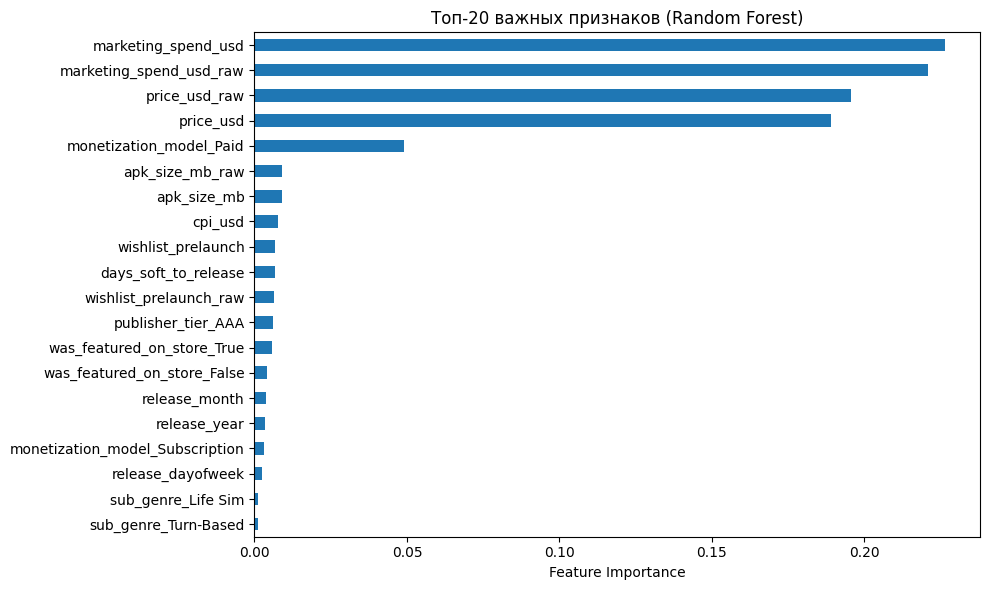

In [14]:
import matplotlib.pyplot as plt

feat_imp = pd.Series(
    rf_best.feature_importances_,
    index=X_train_encoded.columns
).sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh')
plt.title('Топ-20 важных признаков (Random Forest)')
plt.xlabel('Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../report/images/rf_feature_importance.png', dpi=150)
plt.show()

## Модель 4 — XGBoost

XGBoost (eXtreme Gradient Boosting) — метод градиентного бустинга. В отличие от Random Forest, деревья строятся последовательно: каждое следующее исправляет ошибки предыдущего.

In [15]:
import xgboost as xgb

xgb_params = {
    'n_estimators': [300, 500],
    'learning_rate': [0.05, 0.1],
    'max_depth': [4, 6, 8],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
xgb_cv = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=RANDOM_STATE, verbosity=0, n_jobs=-1),
    param_distributions=xgb_params,
    n_iter=16,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
xgb_cv.fit(X_train_encoded, y_train)
print("Лучшие параметры XGB:", xgb_cv.best_params_)
xgb_best = xgb_cv.best_estimator_

Лучшие параметры XGB: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


Добавим результат.

In [16]:
res_xgb = evaluate("XGBoost", xgb_best, X_val_encoded, y_val)
results.append(res_xgb)

XGBoost: RMSE=1.3473, MAE=1.0269, R²=0.5445


## Модель 5 — LightGBM

LightGBM — ещё один метод градиентного бустинга. Строит деревья по листьям (leaf-wise), а не по уровням (level-wise), как XGBoost.

In [17]:
import lightgbm as lgb

lgb_params = {
    'n_estimators': [300, 500],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 63, 127],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
lgb_cv = RandomizedSearchCV(
    lgb.LGBMRegressor(random_state=RANDOM_STATE, verbosity=-1, n_jobs=-1),
    param_distributions=lgb_params,
    n_iter=16,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
lgb_cv.fit(X_train_encoded, y_train)
print("Лучшие параметры LGB:", lgb_cv.best_params_)
lgb_best = lgb_cv.best_estimator_

Лучшие параметры LGB: {'subsample': 0.8, 'num_leaves': 31, 'n_estimators': 300, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


Добавим результат.

In [18]:
res_lgb = evaluate("LightGBM", lgb_best, X_val_encoded, y_val)
results.append(res_lgb)

LightGBM: RMSE=1.3693, MAE=1.0453, R²=0.5295


## Предварительный итог

Получился следующий результат:

| Модель | RMSE | MAE | R² | Место по RMSE |
|:---|:---:|:---:|:---:|:---:|
| Baseline (Ridge) | 1.3366 | 1.0160 | 0.5517 | 2 |
| Lasso Regression | **1.3348** | **1.0144** | **0.5529** | 1 |
| Decision Tree | 1.3669 | 1.0456 | 0.5311 | 6 |
| Random Forest | 1.3485 | 1.0246 | 0.5437 | 4 |
| XGBoost | 1.3473 | 1.0269 | 0.5445 | 3 |
| LightGBM | 1.3693 | 1.0453 | 0.5295 | 5 |

Минимальное значение RMSE показала модель Lasso Regression. Занимательно, что базовая модель Baseline занимает 2 место.
Скорее всего, из-за синтетики данных линейные закономерности доминируют, иначе нелинейные модели вырвались бы вперёд.

## Ансамбль – Stacking

Попробуем применить ансамбль, взяв лучшее от каждой модели. В качестве базовых возьмём Lasso (линейная), XGBoost (бустинг) и Random Forest (бэггинг).

In [21]:
from sklearn.ensemble import StackingRegressor
estimators = [
    ('lasso',  lasso_best),
    ('xgb', xgb_best),
    ('rf', rf_best),
]
stacking = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(),
    cv=5,
    n_jobs=-1
)
stacking.fit(X_train_encoded, y_train)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.","[('lasso', ...), ('xgb', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA regressor which will be used to combine the base estimators.The default regressor is a :class:`~sklearn.linear_model.RidgeCV`.",Ridge()
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",-1
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.001
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",5000


Добавим ансамбль в результат.

In [22]:
res_stack = evaluate("Stacking (Lasso+XGB+RF)", stacking, X_val_encoded, y_val)
results.append(res_stack)

Stacking (Lasso+XGB+RF): RMSE=1.3342, MAE=1.0131, R²=0.5533


Результат стал чуточку лучше (`1.3342` против `1.3348` у Lasso).

## Уменьшение размерности – PCA

Проверим, поможет ли PCA: снижение размерности уменьшает шум или, наоборот, ухудшает качество, потеряв важную информацию?

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_val_scaled   = scaler.transform(X_val_encoded)

pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_95 = np.searchsorted(cumvar, 0.95) + 1
n_99 = np.searchsorted(cumvar, 0.99) + 1

Визуализируем.

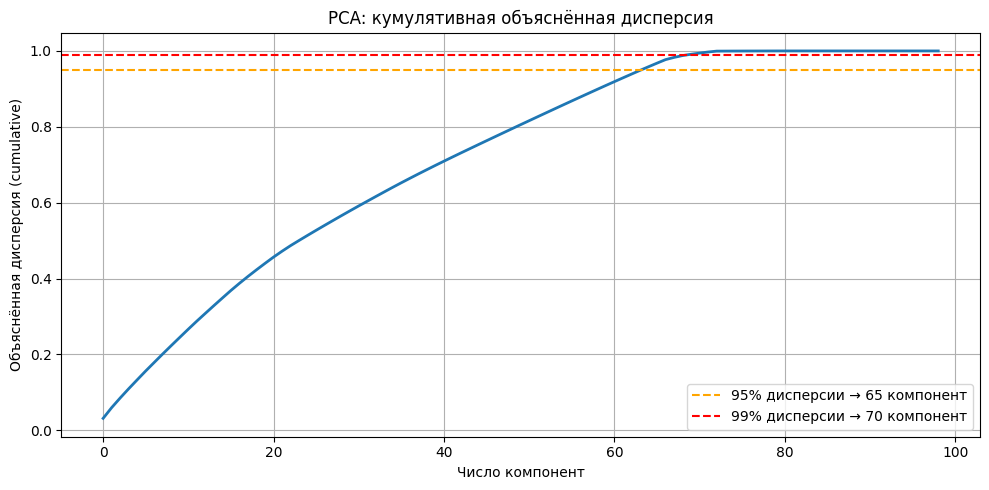

In [25]:
plt.figure(figsize=(10, 5))
plt.plot(cumvar, linewidth=2)
plt.axhline(0.95, color='orange', linestyle='--', label=f'95% дисперсии → {n_95} компонент')
plt.axhline(0.99, color='red',    linestyle='--', label=f'99% дисперсии → {n_99} компонент')
plt.xlabel('Число компонент')
plt.ylabel('Объяснённая дисперсия (cumulative)')
plt.title('PCA: кумулятивная объяснённая дисперсия')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../report/images/pca_variance.png', dpi=150)
plt.show()

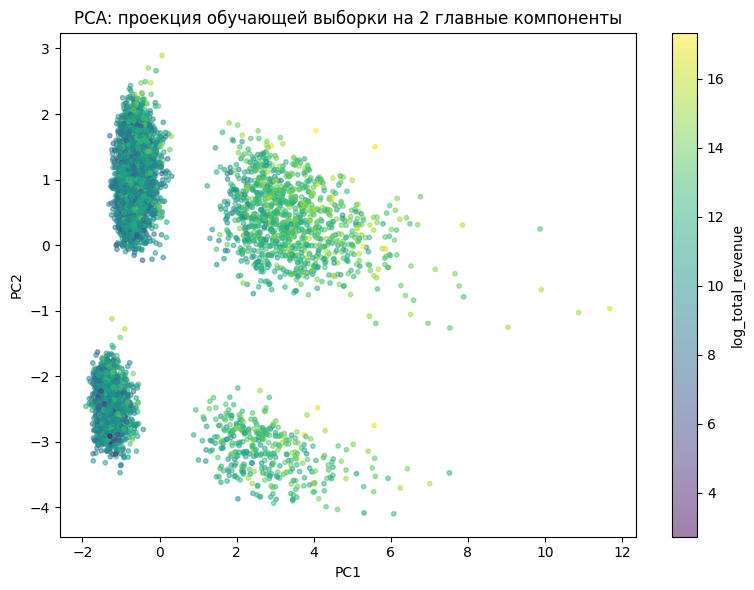

In [ ]:
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca_2d.fit_transform(X_train_scaled)

plt.figure(figsize=(8, 6))
sc = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_train, cmap='viridis', alpha=0.5, s=10)
plt.colorbar(sc, label='log_total_revenue')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA: проекция обучающей выборки на 2 главные компоненты')
plt.tight_layout()
plt.show()

Теперь проведём эксперимент с разным числом PCA-компонент.

In [27]:
pca_results = []
for n_comp in [10, 20, 50, n_95, n_99, X_train_scaled.shape[1]]:
    n_comp = min(n_comp, X_train_scaled.shape[1])
    pca = PCA(n_components=n_comp, random_state=RANDOM_STATE)
    Xtr_pca = pca.fit_transform(X_train_scaled)
    Xval_pca = pca.transform(X_val_scaled)
    
    m = xgb.XGBRegressor(
        **{k: v for k, v in lasso_best.get_params().items()},
        verbosity=0, n_jobs=-1
    )
    m.fit(Xtr_pca, y_train)
    y_pred = m.predict(Xval_pca)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    pca_results.append({'n_components': n_comp, 'RMSE': rmse})
    print(f"PCA({n_comp:4d} компонент) → RMSE={rmse:.4f}")

PCA(  10 компонент) → RMSE=1.5874
PCA(  20 компонент) → RMSE=1.5857
PCA(  50 компонент) → RMSE=1.5127
PCA(  65 компонент) → RMSE=1.4987
PCA(  70 компонент) → RMSE=1.4924
PCA(  99 компонент) → RMSE=1.4711


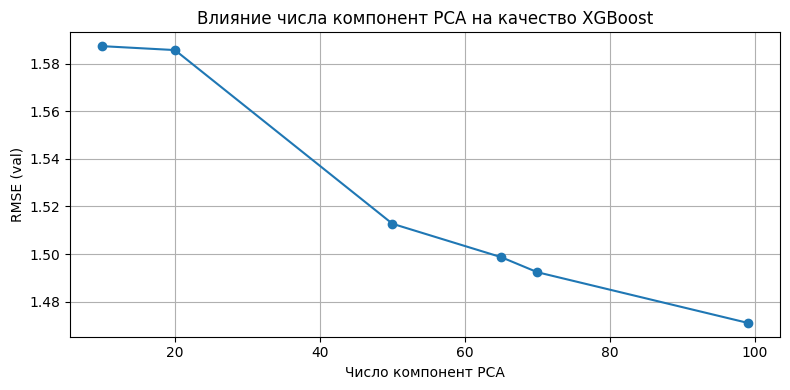

In [ ]:
pca_df = pd.DataFrame(pca_results)
plt.figure(figsize=(8, 4))
plt.plot(pca_df['n_components'], pca_df['RMSE'], marker='o')
plt.xlabel('Число компонент PCA')
plt.ylabel('RMSE (val)')
plt.title('Влияние числа компонент PCA на качество XGBoost')
plt.grid(True)
plt.tight_layout()
plt.show()

Эксперимент получился неудачный, поскольку RMSE стала выше.

## Таблица экспериментов

In [29]:
results_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
results_df.index += 1  # нумерация с 1

# Стилизация: выделяем лучшие значения
styled = results_df.style\
    .highlight_min(subset=['RMSE', 'MAE'], color='lightgreen')\
    .highlight_max(subset=['R²'],          color='lightgreen')\
    .format({'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'R²': '{:.4f}'})

print("Таблица результатов (отсортировано по RMSE ↑):")
display(styled)

Таблица результатов (отсортировано по RMSE ↑):


,Модель,RMSE,MAE,R²
1,Stacking (Lasso+XGB+RF),1.3342,1.0131,0.5533
2,Lasso Regression,1.3348,1.0144,0.5529
3,Baseline,1.3366,1.0160,0.5517
4,XGBoost,1.3473,1.0269,0.5445
5,Random Forest,1.3485,1.0246,0.5437
6,Decision Tree,1.3669,1.0456,0.5311
7,LightGBM,1.3693,1.0453,0.5295


## 10. Тестовая выборка

Тестовую выборку используем **один раз** — только для итоговой оценки финальной модели. Выбираем модель с лучшим RMSE на валидации.

In [31]:
# Определяем лучшую модель по val RMSE
best_row = results_df.iloc[0]
print(f"Лучшая модель по валидации: {best_row['Модель']}")
print(f"Val  → RMSE={best_row['RMSE']:.4f}, MAE={best_row['MAE']:.4f}, R²={best_row['R²']:.4f}")

# Сопоставляем имя с объектом модели
model_map = {
    'Lasso Regression':           lasso_best,
    'Decision Tree':               dt_best,
    'Random Forest':               rf_best,
    'XGBoost':                     xgb_best,
    'LightGBM':                    lgb_best,
    'Stacking (Lasso+XGB+RF)': stacking
}
final_model = model_map.get(best_row['Модель'], baseline_model)

Лучшая модель по валидации: Stacking (Lasso+XGB+RF)
Val  → RMSE=1.3342, MAE=1.0131, R²=0.5533


In [32]:
y_test_pred = final_model.predict(X_test_encoded)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae  = mean_absolute_error(y_test, y_test_pred)
test_r2   = r2_score(y_test, y_test_pred)
print(f"\nTest → RMSE={test_rmse:.4f}, MAE={test_mae:.4f}, R²={test_r2:.4f}")


Test → RMSE=1.3246, MAE=1.0066, R²=0.5703


Построим график: предсказанные и реальные значения на тесте.

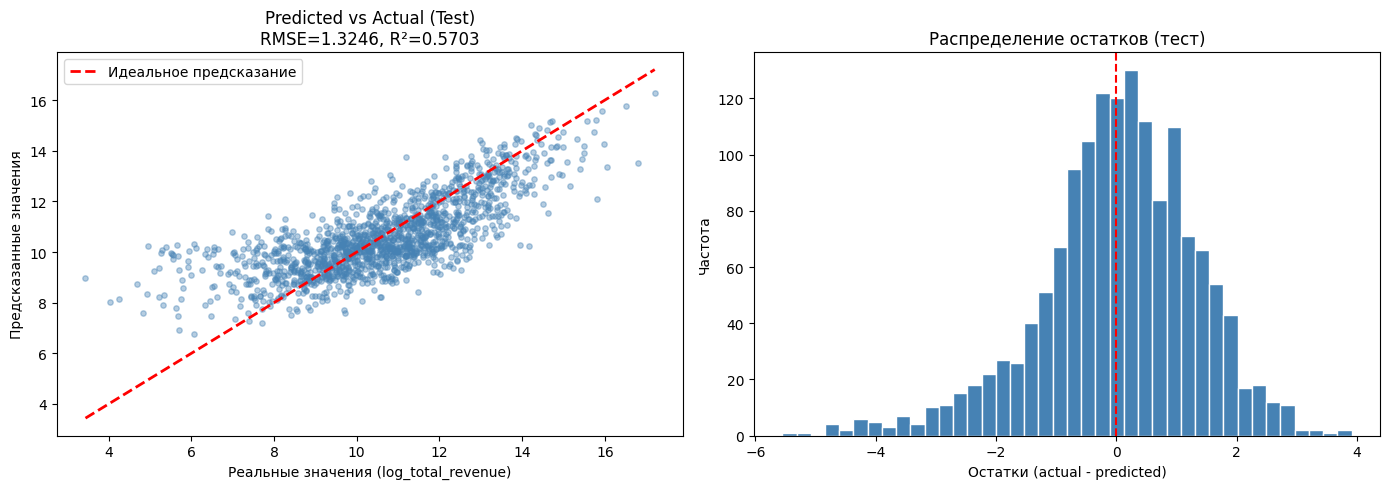

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_test_pred, alpha=0.4, s=15, color='steelblue')
mn = min(y_test.min(), y_test_pred.min())
mx = max(y_test.max(), y_test_pred.max())
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Идеальное предсказание')
axes[0].set_xlabel('Реальные значения (log_total_revenue)')
axes[0].set_ylabel('Предсказанные значения')
axes[0].set_title(f'Predicted vs Actual (Test)\nRMSE={test_rmse:.4f}, R²={test_r2:.4f}')
axes[0].legend()

residuals = y_test - y_test_pred
axes[1].hist(residuals, bins=40, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Остатки (actual - predicted)')
axes[1].set_ylabel('Частота')
axes[1].set_title('Распределение остатков (тест)')

plt.tight_layout()
plt.savefig('../report/images/final_model_test.png', dpi=150)
plt.show()

## Вывод

Модель улавливает общую тенденцию. Но в левой части точки систематически выше диагонали — модель **переоценивает** доход у дешёвых игр, а в правой части, наоборот, точки ниже диагонали — модель **недооценивает** доход у самых прибыльных игр.

Распределение остатков близко к нормальному и центрировано около нуля — значит, модель в среднем не систематически ошибается ни в плюс, ни в минус. Тем не менее распределение немного скошено влево (левый хвост длиннее). Это согласуется с первым графиком.

Сохраним полученную модель.

In [34]:
import os
import joblib

os.makedirs('../models', exist_ok=True)
joblib.dump(final_model, '../models/final_model.pkl')
joblib.dump(ohe,         '../models/ohe.pkl')
print("Модель сохранена в ../models/final_model.pkl")

Модель сохранена в ../models/final_model.pkl


## Итог

Финальная модель — **Stacking (Lasso + XGBoost + Random Forest)** с подобранными
гиперпараметрами базовых моделей. Комбинирование моделей
разных классов (линейной, бустинга и бэггинга) позволило мета-модели использовать
сильные стороны каждой из них.